In [1]:
import Pkg
Pkg.activate("../")
using Revise 
using Eliashberg
using Plots

  Activating project at `/home/users/y/i/yimzhang/aiida_projects/supercon/pkgs/Eliashberg`
Precompiling Eliashberg
  ✓ Eliashberg
  1 dependency successfully precompiled in 2 seconds. 157 already precompiled.


In [2]:
kgrid = collect(range(-2, 2, length=1001))
EF = 2.0 # eV
T = 10 * 8.617333262145e-5 # e
V0 = -0.1 # eV
fswindow = 0.1 # eV

0.1

In [3]:

free_electron_1d = Eliashberg.BCS.FreeElectron_1d(EF)
E_gs =  [Eliashberg.BCS.ε(k, free_electron_1d) for k in kgrid]

constant_interaction_1d = Eliashberg.BCS.ConstantInteraction_1d(V0)
limited_constant_interaction_1d = Eliashberg.BCS.LimitedConstantInteraction(
    V0, fswindow, free_electron_1d)
local_interaction_1d = Eliashberg.BCS.LocalInteraction_1d(
    V0, 1e-6, fswindow)

E_cst_f, phi = Eliashberg.BCS.solve_bcs(
    kgrid, free_electron_1d, constant_interaction_1d)
E_ltd_cst_f, phi = Eliashberg.BCS.solve_bcs(
    kgrid, free_electron_1d, limited_constant_interaction_1d)
E_local_f, phi = Eliashberg.BCS.solve_bcs(
    kgrid, free_electron_1d, local_interaction_1d)
print(kgrid)
println(E_gs)
println(E_ltd_cst_f)
plot(kgrid, E_gs, label="constant potential")
plot!(kgrid, E_ltd_cst_f, label="constant potential with window")
plot!(kgrid, E_local_f, label="local potential")

LoadError: MethodError: no method matching V(::Float64, ::Float64, ::Eliashberg.BCS.ConstantInteraction_1d, ::Eliashberg.BCS.FreeElectron_1d)

[0mClosest candidates are:
[0m  V(::Float64, ::Float64, ::Eliashberg.BCS.ConstantInteraction_1d)
[0m[90m   @[39m [35mEliashberg[39m [90m/home/users/y/i/yimzhang/aiida_projects/supercon/pkgs/Eliashberg/src/[39m[90m[4minteractions.jl:31[24m[39m
[0m  V(::Float64, ::Float64, [91m::Eliashberg.BCS.LimitedConstantInteraction[39m, ::Eliashberg.BCS.ElectronicDispersion)
[0m[90m   @[39m [35mEliashberg[39m [90m/home/users/y/i/yimzhang/aiida_projects/supercon/pkgs/Eliashberg/src/[39m[90m[4minteractions.jl:60[24m[39m
[0m  V(::Float64, ::Float64, [91m::Eliashberg.BCS.LocalInteraction_1d[39m, ::Eliashberg.BCS.ElectronicDispersion)
[0m[90m   @[39m [35mEliashberg[39m [90m/home/users/y/i/yimzhang/aiida_projects/supercon/pkgs/Eliashberg/src/[39m[90m[4minteractions.jl:39[24m[39m
[0m  ...


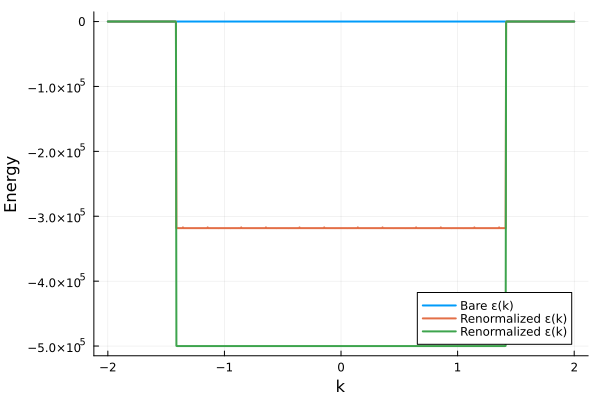

In [6]:
free_electron_1d = Eliashberg.BCS.FreeElectron_1d(EF)

fd = Eliashberg.BCS.FermiDiracSmearing(T)

bare_Coulomb = Eliashberg.BCS.BareCoulombInteraction(1e-6)
screened_Coulomb = Eliashberg.BCS.ScreenedCoulombInteraction(0.000001)

hf_bare_Coulomb = Eliashberg.BCS.HartreeFockSelfEnergy(bare_Coulomb, fd, free_electron_1d)
hf_screened_Coulomb = Eliashberg.BCS.HartreeFockSelfEnergy(screened_Coulomb, fd, free_electron_1d)

renormalized_by_bare_Coulomb = Eliashberg.BCS.RenormalizedDispersion(free_electron_1d, hf_bare_Coulomb)
renormalized_by_screened_Coulomb = Eliashberg.BCS.RenormalizedDispersion(free_electron_1d, hf_screened_Coulomb)

dispersion_free_electron = [Eliashberg.BCS.ε(k, free_electron_1d) for k in kgrid]
dispersion_renormalized_by_bare_Coulomb = [Eliashberg.BCS.ε(k, renormalized_by_bare_Coulomb) for k in kgrid]
dispersion_renormalized_by_screened_Coulomb = [Eliashberg.BCS.ε(k, renormalized_by_screened_Coulomb) for k in kgrid]

plot(kgrid, dispersion_free_electron, label="Bare ε(k)", lw=2)
plot!(kgrid, dispersion_renormalized_by_bare_Coulomb, label="Renormalized ε(k)", lw=2)
plot!(kgrid, dispersion_renormalized_by_screened_Coulomb, label="Renormalized ε(k)", lw=2)

xlabel!("k"); ylabel!("Energy")

